In [2]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

import pymc as pm
import pytensor.tensor as pt
import pytensor
from tqdm.notebook import tqdm
pytensor.config.cxx = '/usr/bin/clang++'

In [3]:
def exponential(n_samples, lambda_like=2.0, seed=20):
    np.random.seed(seed)
    data = np.random.exponential(1 / lambda_like, n_samples)
    return data

def load_config(config_file="config.json"):
    with open(config_file, 'r') as f:
        config = json.load(f)
    return config

def pushforward_exp_mean_std(mu, sigma):
    mu = float(np.asarray(mu).squeeze())
    sigma = float(np.asarray(sigma).squeeze())
    if sigma < 0:
        raise ValueError(f"sigma must be nonnegative, got {sigma}")

    mean = np.exp(mu + 0.5 * sigma**2)
    var  = (np.exp(sigma**2) - 1.0) * np.exp(2.0 * mu + sigma**2)
    std  = np.sqrt(var)
    return float(mean), float(std)


def traces_to_lambda_moments(mu_trace, sigma_trace):
    mu_trace = np.asarray(mu_trace, dtype=float).reshape(-1)
    sigma_trace = np.asarray(sigma_trace, dtype=float).reshape(-1)

    if mu_trace.shape[0] != sigma_trace.shape[0]:
        raise ValueError("mu_trace and sigma_trace must have the same length")

    mean = np.exp(mu_trace + 0.5 * sigma_trace**2)
    var  = (np.exp(sigma_trace**2) - 1.0) * np.exp(2.0 * mu_trace + sigma_trace**2)
    std  = np.sqrt(var)
    return mean, std

In [4]:
config_file = '../exp_config.json'
config = load_config(config_file)

lambda_like = config['lambda_like']
alpha_prior = config['alpha_prior']
beta_prior = config['beta_prior']
n_samples = config['n_samples']
grad_samps = config['grad_samps']
max_iters = 100_000#config['max_iters']
adam_step = 1e-3#config['adam_step']
data = exponential(n_samples)

In [5]:
def run_model(n_mc_samples = 1, optimizer = 'default', seed = 0):

    with pm.Model() as model:
        lambd = pm.Gamma('lambda', alpha=alpha_prior, beta=beta_prior)

        # Likelihood
        likelihood = pm.Exponential('likelihood', lam=1/lambd, observed=data)

        # Posterior sampling
        advi = pm.ADVI(random_seed=seed)

        tracker = pm.callbacks.Tracker(
            mean = advi.approx.mean.eval,
            std = advi.approx.std.eval,
        )
        if optimizer == 'default':
            approx = advi.fit(
                max_iters, callbacks=[tracker],
                progressbar=False,
                obj_n_mc=n_mc_samples,
            )
        elif optimizer == 'adam':
            approx = advi.fit(
                max_iters, callbacks=[tracker],
                progressbar=False,
                obj_n_mc=n_mc_samples,
                obj_optimizer=pm.adam()#learning_rate=adam_step)
            )
    return tracker['mean'], tracker['std']


def run_restart(seed):
    single_loc_trace, single_scale_trace = run_model(n_mc_samples=1, optimizer='default', seed=seed)
    multi_loc_trace, multi_scale_trace = run_model(n_mc_samples=100, optimizer='default', seed=seed+1000)
    adam_single_loc_trace, adam_single_scale_trace = run_model(n_mc_samples=1, optimizer='adam', seed=seed)
    adam_multi_loc_trace, adam_multi_scale_trace = run_model(n_mc_samples=100, optimizer='adam', seed=seed+1000)

    return [single_loc_trace, single_scale_trace], [multi_loc_trace, multi_scale_trace], [adam_single_loc_trace, adam_single_scale_trace], [adam_multi_loc_trace, adam_multi_scale_trace]

In [ ]:
results = []
adam_results = []
for seed in tqdm(range(5)):
    result = run_restart(seed)
    results.append(result[:2])
    adam_results.append(result[2:])

  0%|          | 0/5 [00:00<?, ?it/s]

Finished [100%]: Average Loss = 0.11851


In [ ]:
plt.rcParams.update({'font.size': 20})
# ----------------------------
# unpack results -> stacks
# ----------------------------
single_means, single_stds = [], []
multi_means,  multi_stds  = [], []
adam_single_means, adam_single_stds = [], []
adam_multi_means, adam_multi_stds = [], []
for single_tracker, multi_tracker in results:
    # ---- Convert PyMC unconstrained traces -> constrained lambda mean/std traces
    single_mus, single_sigmas = traces_to_lambda_moments(
        single_tracker[0], single_tracker[1]
    )
    multi_mus, multi_sigmas = traces_to_lambda_moments(
        multi_tracker[0], multi_tracker[1]
    )
    single_means.append(single_mus)
    single_stds.append(single_sigmas)
    multi_means.append(multi_mus)
    multi_stds.append(multi_sigmas)
for single_tracker, multi_tracker in adam_results:
    # ---- Convert PyMC unconstrained traces -> constrained lambda mean/std traces
    single_mus, single_sigmas = traces_to_lambda_moments(
        single_tracker[0], single_tracker[1]
    )
    multi_mus, multi_sigmas = traces_to_lambda_moments(
        multi_tracker[0], multi_tracker[1]
    )
    adam_single_means.append(single_mus)
    adam_single_stds.append(single_sigmas)
    adam_multi_means.append(multi_mus)
    adam_multi_stds.append(multi_sigmas)

single_means = np.stack(single_means, axis=0)  # (N, T)
single_stds  = np.stack(single_stds,  axis=0)  # (N, T)
multi_means  = np.stack(multi_means,  axis=0)  # (N, T)
multi_stds   = np.stack(multi_stds,   axis=0)  # (N, T)
adam_single_means = np.stack(adam_single_means, axis=0)  # (N, T)
adam_single_stds  = np.stack(adam_single_stds,  axis=0)  # (N, T)
adam_multi_means  = np.stack(adam_multi_means,  axis=0)  # (N, T)
adam_multi_stds   = np.stack(adam_multi_stds,   axis=0)  # (N, T)

N, T = single_means.shape
single_means = single_means.reshape(N, T)
single_stds  = single_stds.reshape(N, T)
multi_means  = multi_means.reshape(N, T)
multi_stds   = multi_stds.reshape(N, T)

adam_single_means = adam_single_means.reshape(N, T)
adam_single_stds  = adam_single_stds.reshape(N, T)
adam_multi_means  = adam_multi_means.reshape(N, T)
adam_multi_stds   = adam_multi_stds.reshape(N, T)
x = np.arange(T)

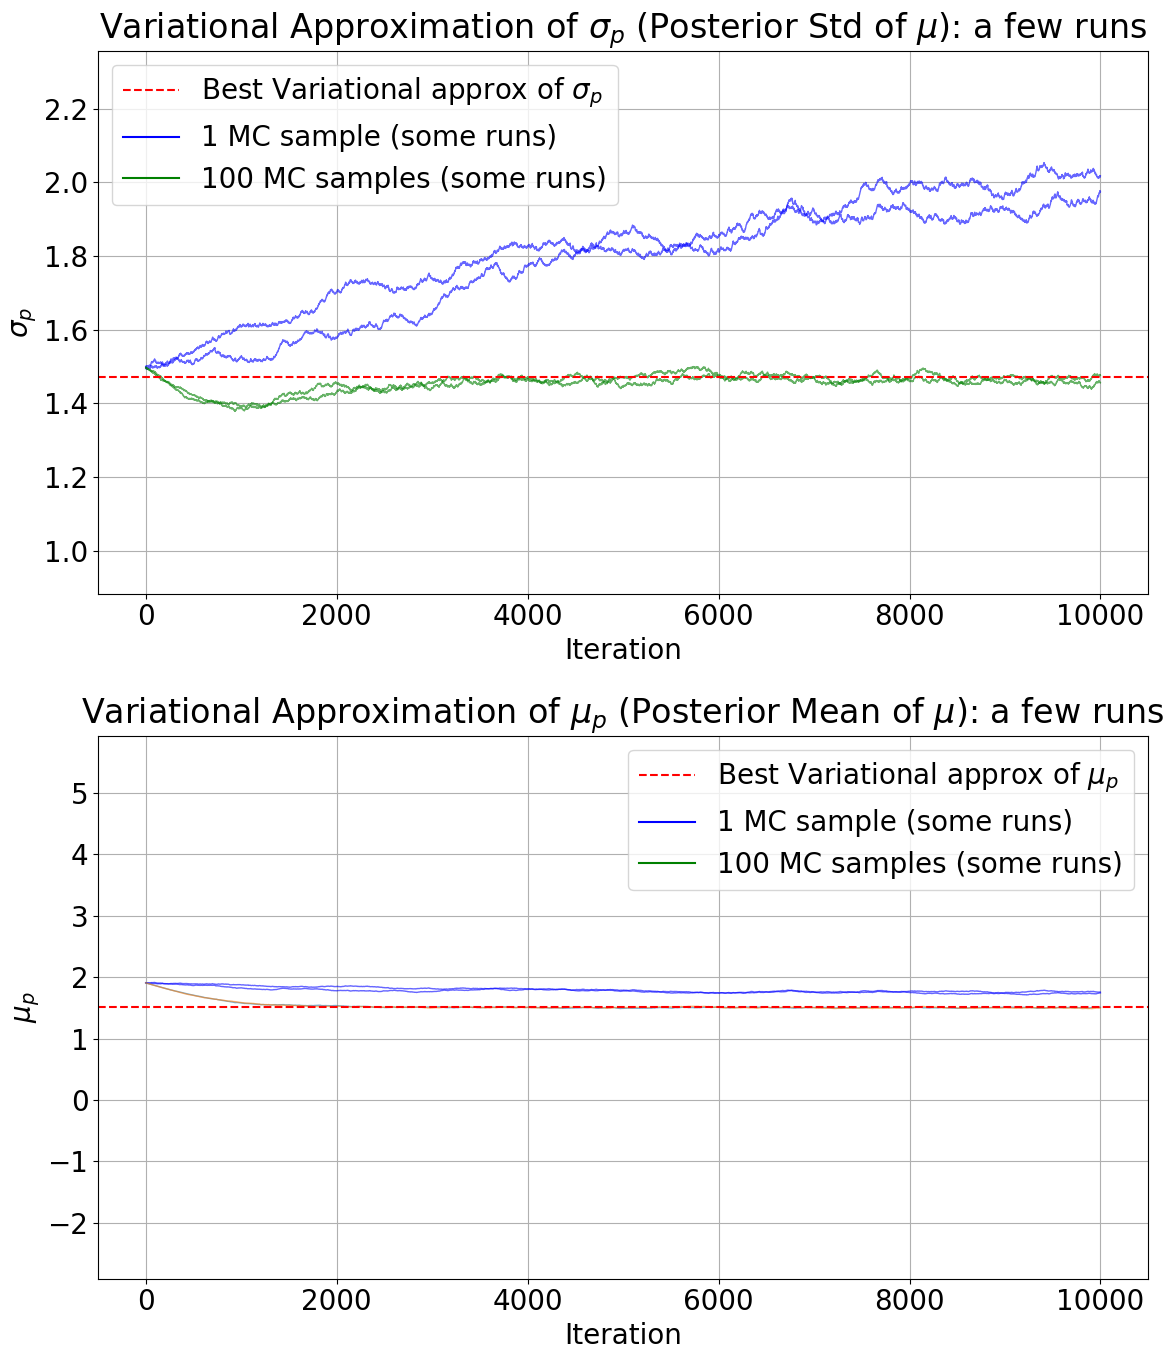

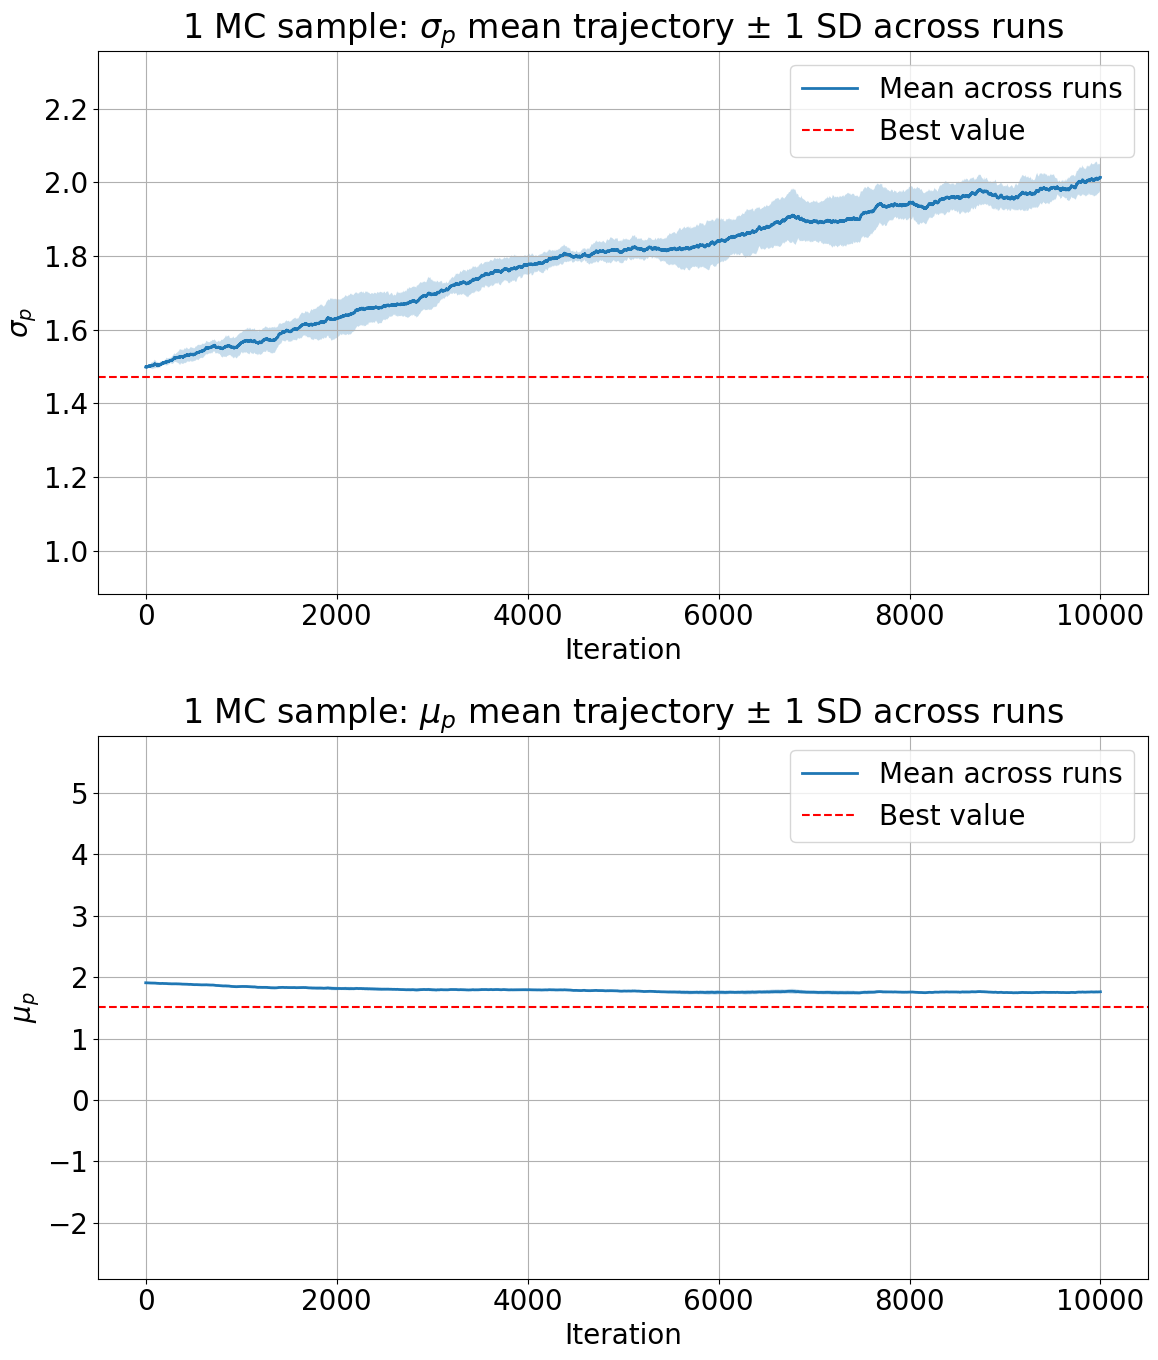

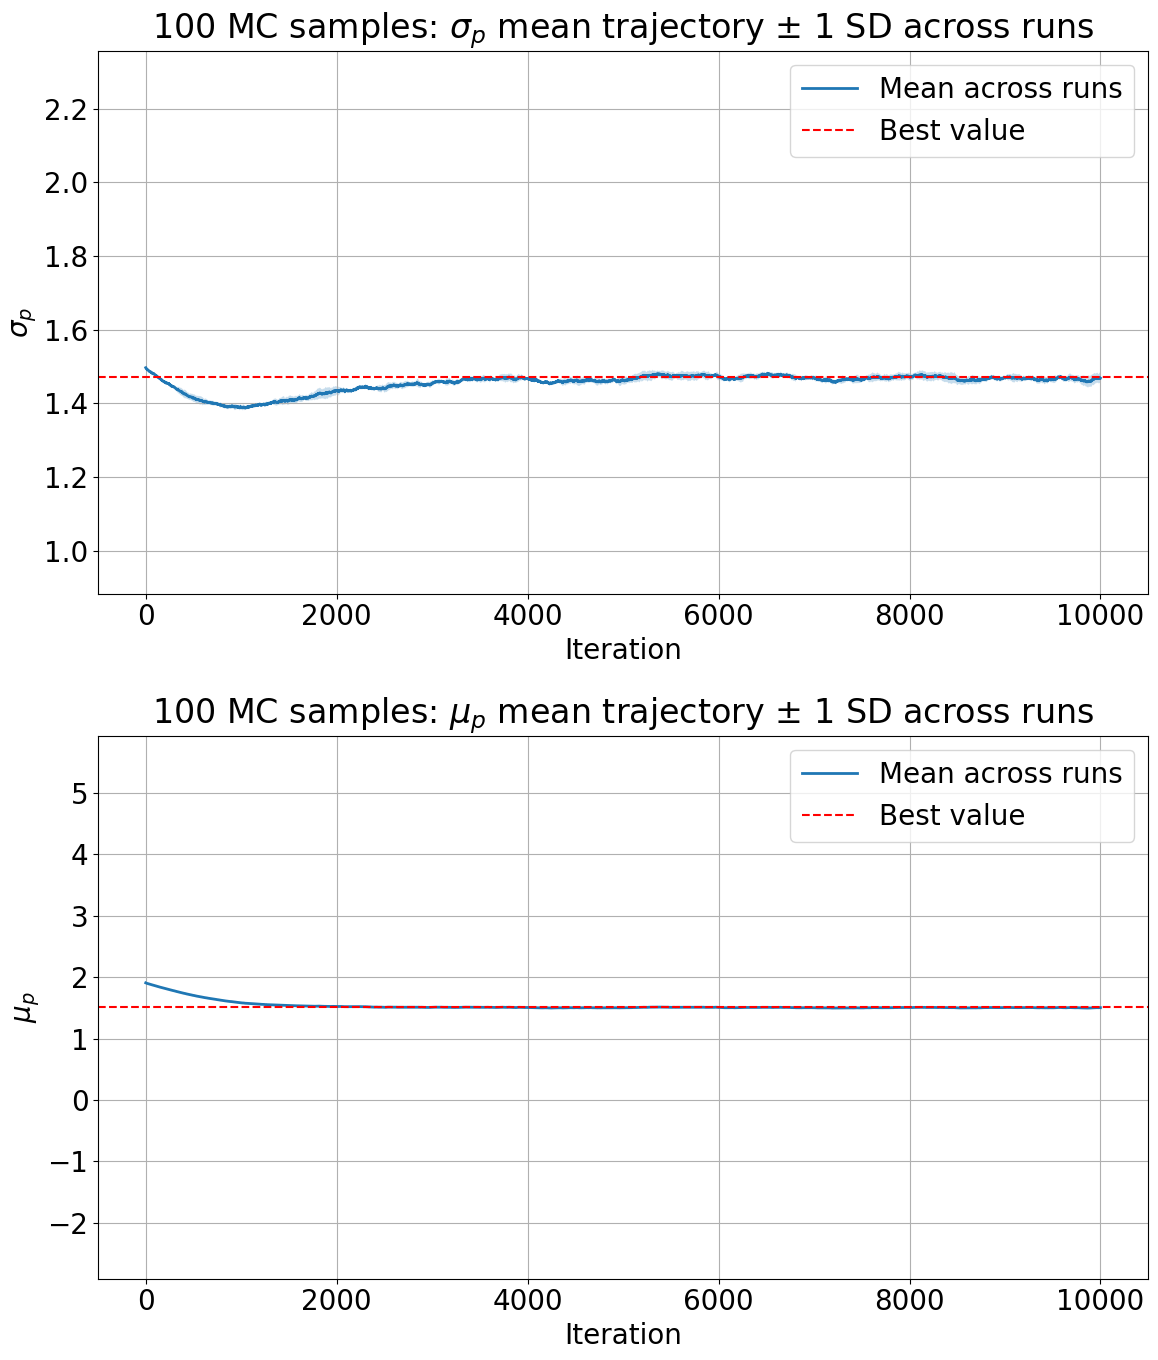

In [ ]:
# convert PyMC traces to lambda moments for plotting
best_mu_unc = config['best_mean']
best_sigma_unc = config['best_std']
best_mu, best_std = pushforward_exp_mean_std(best_mu_unc, best_sigma_unc)

# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, single_stds[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, multi_stds[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(best_std, color='red', linestyle='--', label=r'Best Variational approx of $\sigma_p$')
axs[0].set_title(r'Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

# mean of mu
for i in idx:
    axs[1].plot(x, single_means[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, multi_means[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(best_mu, color='red', linestyle='--', label=r'Best Variational approx of $\mu_p$')
axs[1].set_title(r'Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

# manual legend (so we don’t get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend()

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory ± 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------
def plot_mean_band(ax, x, Y, true_value, title, ylabel):
    """
    Y: (N, T) trajectories
    """
    m = Y.mean(axis=0)
    s = Y.std(axis=0)
    ax.plot(x, m, linewidth=2, label='Mean across runs')
    ax.fill_between(x, m - s, m + s, alpha=0.25)
    ax.axhline(true_value, color='red', linestyle='--', label='Best value')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.grid()
    ax.legend()

# 1 MC sample: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, single_stds, best_std,
    r'1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

plot_mean_band(
    axs[1], x, single_means, best_mu,
    r'1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

plt.tight_layout()
plt.show()

# 100 MC samples: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, multi_stds, best_std,
    r'100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

plot_mean_band(
    axs[1], x, multi_means, best_mu,
    r'100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

plt.tight_layout()
plt.show()

# Adam results

In [ ]:

# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, adam_single_stds[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, adam_multi_stds[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(best_std, color='red', linestyle='--', label=r'Best Variational approx of $\sigma_p$')
axs[0].set_title(r'(ADAM) Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(best_std * 0.6, best_std * 1.4)

# mean of mu
for i in idx:
    axs[1].plot(x, adam_single_means[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, adam_multi_means[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(best_mu, color='red', linestyle='--', label=r'Best Variational approx of $\mu_p$')
axs[1].set_title(r'(ADAM) Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

# manual legend (so we don’t get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend()

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory ± 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------


# 1 MC sample: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, adam_single_stds, best_std,
    r'(ADAM) 1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.4)

plot_mean_band(
    axs[1], x, adam_single_means, best_mu,
    r'(ADAM) 1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

plt.tight_layout()
plt.show()

# 100 MC samples: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, adam_multi_stds, best_std,
    r'(ADAM) 100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.4)

plot_mean_band(
    axs[1], x, adam_multi_means, best_mu,
    r'(ADAM) 100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

plt.tight_layout()
plt.show()

NameError: name 'np' is not defined